# Perturb-Seqr: Cardarine (GW501516) — Term Search -> Mimicker / Gene-Knockout Query

This notebook:

1. **Term-searches** Perturb-Seqr for gene sets matching `Cardarine`, using the
   real metadata search field (`geneSets(condition: {libraryId: ...})`,
   paginated per library) discovered via GraphQL introspection -- a genuine
   name/metadata lookup, independent of any gene-overlap computation.
2. Groups the matching gene sets into **up/down signature pairs** (one
   treatment/dose usually produces one "up" gene set and one "down" gene set).
3. For **each** relevant signature pair, fetches its full member gene lists
   directly (`geneSet(id).genes.nodes.symbol` -- no workarounds needed) and
   runs a **paired up/down enrichment query** against the rest of the
   database to find:
   - **Drug mimickers/reversers** -- other compounds with a similar/opposite signature
   - **Gene knockouts** -- CRISPR/gene-perturbation experiments that phenocopy or reverse it

**Note on an earlier approach:** an earlier version of this notebook tried to
use the `enrich(filterTerm: ...)` resolver as a standalone name search. That
resolver only returns a gene set if it has nonzero overlap with the genes you
supply, so it answers "does my gene list match anything named X" rather than
"show me everything named X" -- it was unreliable for pure discovery. This
version uses the dedicated `geneSets` metadata query instead, which doesn't
have that limitation.


In [2]:
!pip install -q requests pandas



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PERTURBSEQR_URL = "https://perturbseqr.maayanlab.cloud/graphql"

pd.set_option("display.max_colwidth", 120)


def gql(query, variables=None, timeout=120):
    payload = {"query": query}
    if variables is not None:
        payload["variables"] = variables
    resp = requests.post(PERTURBSEQR_URL, json=payload, timeout=timeout)
    resp.raise_for_status()
    res = resp.json()
    if "errors" in res:
        raise RuntimeError(res["errors"])
    return res["data"]


## Helper functions

In [4]:
def parse_perturbation_term(term):
    """
    Split a Perturb-Seqr gene-set 'term' string into (perturbation_name, direction).

    Example:
        parse_perturbation_term("Cardarine::U2OS::::24h::1uM::NSN:BA-74-EG74 up")
        -> ("Cardarine", "up")
    """
    fields = term.split("::")
    perturbation = fields[0].strip()
    last_field = fields[-1].strip() if fields else ""
    tokens = last_field.split(" ")
    direction = tokens[-1].lower() if len(tokens) > 1 and tokens[-1].lower() in ("up", "down") else None
    return perturbation, direction


def base_key(term):
    """
    Grouping key shared by the 'up' and 'down' halves of the *same* experimental
    signature: everything except the final '::'-delimited field (which encodes
    dose/size/direction and legitimately differs between the up and down sides).
    """
    fields = term.split("::")
    return "::".join(fields[:-1]) if len(fields) > 1 else fields[0]


## Step 0 -- Load libraries

Perturb-Seqr aggregates several independent datasets ("libraries"), each with
its own UUID. We fetch the list once and search each one individually.


In [5]:
_libs_data = gql("{ geneSetLibraries { nodes { id name } totalCount } }")
LIBRARIES = _libs_data["geneSetLibraries"]["nodes"]
LIBRARY_NAME_BY_ID = {l["id"]: l["name"] for l in LIBRARIES}

print(f"{len(LIBRARIES)} libraries:")
for l in LIBRARIES:
    print(f"  {l['name']}  ({l['id']})")

# Categorize libraries into "drug/chemical perturbation" vs. "gene perturbation/knockout",
# used later to split mimicker results into drugs vs. gene knockouts.
DRUG_LIBRARY_NAMES = {
    "LINCS L1000 CP", "RummaGEO Chem", "Microarrays CMAP", "SciPlex",
    "CREEDS Chem", "Ginkgo Bioworks", "DeepCover MoA", "NIBR DRUG-seq", "Tahoe-100M",
}
GENE_LIBRARY_NAMES = {
    "CM4AI", "Perturb Atlas Human", "CREEDS Gene", "Replogle et al.",
    "LINCS L1000 XPR", "Perturb Atlas Mouse", "RummaGEO Gene",
}

def classify_library(name):
    if name in DRUG_LIBRARY_NAMES:
        return "drug"
    if name in GENE_LIBRARY_NAMES:
        return "gene_perturbation"
    return "unknown"


16 libraries:
  CM4AI  (0d3c3255-f7f5-4c8e-9b54-9f1620d979f4)
  LINCS L1000 CP  (2cf7e10c-5c3f-41f7-b325-f9459956b4d3)
  RummaGEO Chem  (37a9942e-cf53-4baa-8157-d274e63dfa04)
  Perturb Atlas Human  (4a337e91-57cd-4e8c-9e7f-e1d1bcb21ecc)
  CREEDS Gene  (4be4349a-4bed-452a-8e8d-dd9fb5e03bfc)
  Replogle et al.  (62f2ff67-063b-4567-b6ba-d528b977ce23)
  LINCS L1000 XPR  (89f75d22-c20d-4927-9b5a-4492eddb0129)
  Microarrays CMAP  (9c0757bd-0365-44ac-8c57-5903ebb7dabd)
  SciPlex  (9c9ace2a-2bd4-44ee-8dd4-731420350b2f)
  CREEDS Chem  (a754729f-1f1c-42c7-a520-b4e552a4db8f)
  Ginkgo Bioworks  (cbe6a5f3-ecd6-4519-a1b3-48127a40410d)
  DeepCover MoA  (d382d54b-d775-42ee-aba9-c65af5228df9)
  NIBR DRUG-seq  (d47be9f1-8033-427b-8383-05a921748af6)
  Tahoe-100M  (dbefd90e-bbd3-45cb-a10b-34bfc935ae44)
  Perturb Atlas Mouse  (de4e7fc9-f4d6-414f-894d-de17e10956f5)
  RummaGEO Gene  (e1c62eeb-c5bd-4855-89e4-a790ebe6cd61)


## Step 1 -- Term search: find gene sets related to Cardarine

For each library, page through its gene sets (lightweight fields only) and
keep any whose `term` or `perturbation` field contains the search string
(case-insensitive). This is a real metadata search -- no gene lists involved,
so it's fast and won't miss weak/low-dose signatures.


In [6]:
GENESETS_BY_LIBRARY_QUERY = """
query GeneSetsByLibrary($libraryId: UUID!, $first: Int!, $offset: Int!) {
  geneSets(condition: { libraryId: $libraryId }, first: $first, offset: $offset) {
    nodes {
      id
      term
      perturbation
      cid
      nGeneIds
    }
    totalCount
  }
}
"""

def term_search(search_term, page_size=2000, sleep=0.1, verbose=True):
    """Search every library's gene sets for a case-insensitive substring match
    against `term` or `perturbation`. Returns a DataFrame of matches."""
    matches = []
    needle = search_term.lower()

    for lib in LIBRARIES:
        offset = 0
        lib_matches = 0
        while True:
            data = gql(GENESETS_BY_LIBRARY_QUERY, {
                "libraryId": lib["id"], "first": page_size, "offset": offset
            })
            page = data["geneSets"]
            nodes = page["nodes"]
            total = page["totalCount"]

            for n in nodes:
                term_hit = needle in n["term"].lower()
                pert_hit = n["perturbation"] is not None and needle in n["perturbation"].lower()
                if term_hit or pert_hit:
                    row = dict(n)
                    row["library"] = lib["name"]
                    matches.append(row)
                    lib_matches += 1

            offset += page_size
            time.sleep(sleep)
            if offset >= total:
                break

        if verbose and lib_matches:
            print(f"  {lib['name']}: {lib_matches} matches")

    return pd.DataFrame(matches)


In [7]:
SEARCH_TERM = "Cardarine"

print(f"Searching all libraries for '{SEARCH_TERM}'...")
df_hits = term_search(SEARCH_TERM)

print(f"\nTotal matching gene sets: {len(df_hits)}")
df_hits[["term", "library", "perturbation", "cid", "nGeneIds", "id"]] if not df_hits.empty else df_hits


Searching all libraries for 'Cardarine'...
  NIBR DRUG-seq: 5 matches

Total matching gene sets: 5


,term,library,perturbation,cid,nGeneIds,id
0,Cardarine::U2OS::::24h::0.01uM::NSN:BA-74-EG74 up,NIBR DRUG-seq,Cardarine,9803963,6,4c0c9dab-3428-41a1-a828-e7797ca386a6
1,Cardarine::U2OS::::24h::10uM::NSN:BA-74-EG74 up,NIBR DRUG-seq,Cardarine,9803963,15,b3e77da5-4233-471f-912f-3a7efdccdb31
2,Cardarine::U2OS::::24h::1uM::NSN:BA-74-EG74 down,NIBR DRUG-seq,Cardarine,9803963,13,d87f2943-72cc-4783-a2d4-622bf36a13d1
3,Cardarine::U2OS::::24h::10uM::NSN:BA-74-EG74 down,NIBR DRUG-seq,Cardarine,9803963,5,eae47a5e-04d5-4b28-b359-6afb67f94f6a
4,Cardarine::U2OS::::24h::1uM::NSN:BA-74-EG74 up,NIBR DRUG-seq,Cardarine,9803963,6,f624adce-3eeb-4812-b51e-22e77ef29c96


## Step 2 -- Group matches into up/down signature pairs

Each real experiment normally produces one "up" gene set and one "down" gene
set sharing the same metadata (cell line, dose, dataset ID, etc.), differing
only in their final `::`-delimited field.


In [8]:
if df_hits.empty:
    df_pairs = pd.DataFrame()
    print("No gene sets found -- nothing to pair.")
else:
    df_hits["base_key"] = df_hits["term"].map(base_key)
    df_hits["direction"] = df_hits["term"].map(lambda t: parse_perturbation_term(t)[1])

    pairs = []
    for key, grp in df_hits.groupby("base_key"):
        up_row = grp[grp["direction"] == "up"]
        down_row = grp[grp["direction"] == "down"]
        pairs.append({
            "base_key": key,
            "perturbation_name": grp["perturbation"].iloc[0] or parse_perturbation_term(grp["term"].iloc[0])[0],
            "library": grp["library"].iloc[0],
            "cid": grp["cid"].iloc[0],
            "id_up": up_row["id"].iloc[0] if not up_row.empty else None,
            "id_down": down_row["id"].iloc[0] if not down_row.empty else None,
            "nGeneIds_up": up_row["nGeneIds"].iloc[0] if not up_row.empty else None,
            "nGeneIds_down": down_row["nGeneIds"].iloc[0] if not down_row.empty else None,
        })
    df_pairs = pd.DataFrame(pairs)
    # keep only complete up+down pairs -- these are what the paired enrichment query needs
    df_pairs = df_pairs[df_pairs["id_up"].notna() & df_pairs["id_down"].notna()].reset_index(drop=True)

print(f"{len(df_pairs)} complete up/down signature pairs found.")
df_pairs


2 complete up/down signature pairs found.


,base_key,perturbation_name,library,cid,id_up,id_down,nGeneIds_up,nGeneIds_down
0,Cardarine::U2OS::::24h::10uM,Cardarine,NIBR DRUG-seq,9803963,b3e77da5-4233-471f-912f-3a7efdccdb31,eae47a5e-04d5-4b28-b359-6afb67f94f6a,15,5.0
1,Cardarine::U2OS::::24h::1uM,Cardarine,NIBR DRUG-seq,9803963,f624adce-3eeb-4812-b51e-22e77ef29c96,d87f2943-72cc-4783-a2d4-622bf36a13d1,6,13.0


## Step 3 -- Fetch full gene lists and run the mimicker/knockout query

For every up/down pair found above:
1. fetch its actual member gene symbols directly (`geneSet(id).genes`)
2. run a paired enrichment query against the whole database to find mimicking/
   reversing signatures (drugs and gene knockouts)


In [9]:
GENESET_GENES_QUERY = """
query GeneSetGenes($id: UUID!) {
  geneSet(id: $id) {
    term
    nGeneIds
    genes(first: 100000) {
      nodes { symbol }
    }
  }
}
"""

def get_full_geneset_genes(gene_set_id):
    data = gql(GENESET_GENES_QUERY, {"id": gene_set_id})
    return [n["symbol"] for n in data["geneSet"]["genes"]["nodes"]]


In [10]:
def enrich_perturbseqr_up_down(genes_up, genes_down, first=200, top_n=10000, pvalue_le=0.05, sort_by="pvalue_mimic"):
    """
    Paired up/down enrichment: find gene sets (drugs or gene knockouts) whose own
    up/down signature significantly mimics (up<->up, down<->down) or reverses
    (up<->down) the input signature.

    Returns (df_enrichment_pair, df_consensus_pair):
      - df_enrichment_pair: one row per individual matching gene set (per-library,
        per-dataset hit) -- used for the per-library charts.
      - df_consensus_pair: aggregated across all matching gene sets per perturbation
        -- used for the summary drug/gene-knockout tables.

    `sort_by` controls which end ("pvalue_mimic" or "pvalue_reverse") gets priority
    within the `first`-row cap on individual hits; call this twice (once per sort)
    if you want good coverage of both the top mimickers and top reversers.
    """
    query = """query PairEnrichmentQuery($genesUp: [String]!, $genesDown: [String]!, $filterTerm: String = "", $offset: Int = 0, $first: Int = 10, $filterFda: Boolean = false, $sortBy: String = "", $filterKo: Boolean = false, $topN: Int = 10000, $pvalueLe: Float = 0.05) {
      currentBackground {
        pairedEnrich(
          filterTerm: $filterTerm
          offset: $offset
          first: $first
          filterFda: $filterFda
          sortby: $sortBy
          filterKo: $filterKo
          topN: $topN
          pvalueLe: $pvalueLe
          genesDown: $genesDown
          genesUp: $genesUp
          ) {
            totalCount
            consensusCount
            consensus {
              drug
              oddsRatio
              pvalue
              adjPvalue
              approved
              countSignificant
              countInsignificant
              countUpSignificant
              pvalueUp
              adjPvalueUp
              oddsRatioUp
              pvalueDown
              adjPvalueDown
              oddsRatioDown
              libraries
              }
            nodes {
              adjPvalueMimic
              adjPvalueReverse
              mimickerOverlap
              oddsRatioMimic
              oddsRatioReverse
              pvalueMimic
              pvalueReverse
              reverserOverlap
              geneSet {
                nodes {
                  id
                  nGeneIds
                  term
                  geneSetFdaCountsById {
                    nodes { count approved }
                  }
                  library { name }
                }
              }
            }
          }
        }
      }
    """
    variables = {
        "filterTerm": "", "offset": 0, "first": first, "filterFda": False,
        "sortBy": sort_by, "filterKo": False, "topN": top_n, "pvalueLe": pvalue_le,
        "genesUp": genes_up, "genesDown": genes_down,
    }
    data = gql(query, variables)
    consensus = data['currentBackground']['pairedEnrich']['consensus']
    nodes = data['currentBackground']['pairedEnrich']['nodes']

    df_consensus_pair = pd.DataFrame(consensus).rename(columns={
        'drug': 'perturbation',
        'pvalueUp': 'pvalueMimic', 'pvalueDown': 'pvalueReverse',
        'adjPvalueUp': 'adjPvalueMimic', 'adjPvalueDown': 'adjPvalueReverse',
        'oddsRatioUp': 'oddsRatioMimic', 'oddsRatioDown': 'oddsRatioReverse',
    })

    if not nodes:
        return pd.DataFrame(), df_consensus_pair

    df_enrichment_pair = pd.DataFrame(nodes)
    # geneSet.nodes holds the candidate perturbation's OWN up + down gene sets --
    # pick term/library/approved from whichever sub-node, and keep both ids in case
    # you want to fetch that candidate's own genes later.
    df_enrichment_pair['term'] = df_enrichment_pair['geneSet'].map(lambda t: t['nodes'][0]['term'].split(' ')[0])
    df_enrichment_pair['library'] = df_enrichment_pair['geneSet'].map(lambda t: t['nodes'][0]['library']['name'])
    df_enrichment_pair['approved'] = df_enrichment_pair['geneSet'].map(
        lambda t: t['nodes'][0]['geneSetFdaCountsById']['nodes'][0]['approved']
        if t['nodes'][0]['geneSetFdaCountsById']['nodes'] else False)
    df_enrichment_pair['geneSetIdUp'] = df_enrichment_pair['geneSet'].map(
        lambda t: next((n['id'] for n in t['nodes'] if ' up' in n['term']), None))
    df_enrichment_pair['geneSetIdDown'] = df_enrichment_pair['geneSet'].map(
        lambda t: next((n['id'] for n in t['nodes'] if ' down' in n['term']), None))
    df_enrichment_pair = df_enrichment_pair.drop(columns=['geneSet'])

    return df_enrichment_pair, df_consensus_pair


In [11]:
MAX_SIGNATURES = 10  # raise to process every pair found in Step 2

extracted = []
for i, row in df_pairs.head(MAX_SIGNATURES).iterrows():
    print(f"Fetching genes for {row['perturbation_name']} ({row['library']}, {row['base_key']})...")
    try:
        genes_up = get_full_geneset_genes(row["id_up"])
        genes_down = get_full_geneset_genes(row["id_down"])
    except Exception as e:
        print(f"  failed: {e}")
        continue
    extracted.append({**row.to_dict(), "genes_up": genes_up, "genes_down": genes_down})
    print(f"  -> {len(genes_up)} up genes, {len(genes_down)} down genes")
    time.sleep(0.2)

print(f"\nExtracted gene lists for {len(extracted)} of {min(len(df_pairs), MAX_SIGNATURES)} signatures.")


Fetching genes for Cardarine (NIBR DRUG-seq, Cardarine::U2OS::::24h::10uM)...
  -> 15 up genes, 5 down genes
Fetching genes for Cardarine (NIBR DRUG-seq, Cardarine::U2OS::::24h::1uM)...
  -> 6 up genes, 13 down genes

Extracted gene lists for 2 of 2 signatures.


In [12]:
all_consensus = []
all_enrichment_mimic = []
all_enrichment_reverse = []

for e in extracted:
    if not e["genes_up"] or not e["genes_down"]:
        print(f"Skipping {e['perturbation_name']} ({e['library']}): empty gene list.")
        continue
    print(f"Running paired enrichment for {e['perturbation_name']} ({e['library']}, {e['base_key']})...")

    try:
        # Call twice: once sorted for the best mimickers, once for the best reversers,
        # so both ends get good coverage within the `first`-row cap on individual hits.
        df_enrich_mimic, df_cons = enrich_perturbseqr_up_down(
            e["genes_up"], e["genes_down"], first=200, top_n=10000, sort_by="pvalue_mimic")
        df_enrich_reverse, _ = enrich_perturbseqr_up_down(
            e["genes_up"], e["genes_down"], first=200, top_n=10000, sort_by="pvalue_reverse")
    except Exception as ex:
        print(f"  failed: {ex}")
        continue

    for df, bucket in ((df_enrich_mimic, all_enrichment_mimic), (df_enrich_reverse, all_enrichment_reverse)):
        if df.empty:
            continue
        df = df.copy()
        df["query_perturbation"] = e["perturbation_name"]
        df["query_signature"] = e["base_key"]
        df["query_library"] = e["library"]
        df["category"] = df["library"].map(classify_library)
        bucket.append(df)

    if df_cons.empty:
        print("  no consensus hits")
    else:
        df_cons = df_cons.copy()
        df_cons["query_perturbation"] = e["perturbation_name"]
        df_cons["query_signature"] = e["base_key"]
        df_cons["query_library"] = e["library"]
        df_cons["category"] = df_cons["libraries"].map(lambda libs: next(
            (classify_library(l) for l in libs if classify_library(l) != "unknown"), "unknown"))
        all_consensus.append(df_cons)
        print(f"  -> {len(df_cons)} consensus hits, {len(df_enrich_mimic)} per-library mimic rows, {len(df_enrich_reverse)} per-library reverse rows")

    time.sleep(0.2)

df_all_consensus = pd.concat(all_consensus, ignore_index=True) if all_consensus else pd.DataFrame()
df_enrichment_mimic = pd.concat(all_enrichment_mimic, ignore_index=True) if all_enrichment_mimic else pd.DataFrame()
df_enrichment_reverse = pd.concat(all_enrichment_reverse, ignore_index=True) if all_enrichment_reverse else pd.DataFrame()

print(f"\nCollected {len(df_all_consensus)} consensus rows and "
      f"{len(df_enrichment_mimic)}/{len(df_enrichment_reverse)} per-library mimic/reverse rows "
      f"across {len(all_consensus)} queried signatures.")


Running paired enrichment for Cardarine (NIBR DRUG-seq, Cardarine::U2OS::::24h::10uM)...
  -> 200 consensus hits, 200 per-library mimic rows, 200 per-library reverse rows
Running paired enrichment for Cardarine (NIBR DRUG-seq, Cardarine::U2OS::::24h::1uM)...
  -> 200 consensus hits, 200 per-library mimic rows, 200 per-library reverse rows

Collected 400 consensus rows and 400/400 per-library mimic/reverse rows across 2 queried signatures.


## Step 4 -- Results: drug mimickers and gene knockouts

In [13]:
DISPLAY_COLS = ["perturbation", "query_perturbation", "query_signature", "query_library",
                "pvalueMimic", "adjPvalueMimic", "oddsRatioMimic",
                "pvalueReverse", "adjPvalueReverse", "oddsRatioReverse",
                "approved", "libraries"]

if df_all_consensus.empty:
    drug_mimickers = pd.DataFrame()
    gene_knockouts = pd.DataFrame()
    print("No consensus results to display.")
else:
    drug_mimickers = df_all_consensus[df_all_consensus["category"] == "drug"] \
        .sort_values("pvalueMimic").reset_index(drop=True)
    gene_knockouts = df_all_consensus[df_all_consensus["category"] == "gene_perturbation"] \
        .sort_values("pvalueMimic").reset_index(drop=True)

    print(f"Drug mimickers/reversers found: {len(drug_mimickers)}")
    print(f"Gene knockout/perturbation hits found: {len(gene_knockouts)}")


Drug mimickers/reversers found: 361
Gene knockout/perturbation hits found: 39


In [14]:
print("Top drug mimickers/reversers of Cardarine signatures:")
drug_mimickers[DISPLAY_COLS].head(30) if not drug_mimickers.empty else drug_mimickers


Top drug mimickers/reversers of Cardarine signatures:


,perturbation,query_perturbation,query_signature,query_library,pvalueMimic,adjPvalueMimic,oddsRatioMimic,pvalueReverse,adjPvalueReverse,oddsRatioReverse,approved,libraries
0,Quinidine,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.010989,0.011905,1,91,True,"[NIBR DRUG-seq, Tahoe-100M]"
1,Hydroxyurea,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.010989,0.011905,1,91,True,[Tahoe-100M]
2,Doxycycline (monohydrate),Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.018182,0.047619,1,55,True,[Tahoe-100M]
3,Ligustrazine,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.018182,0.047619,1,55,False,[Tahoe-100M]
4,Tetracycline (hydrochloride),Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.018182,0.047619,1,55,True,[Tahoe-100M]
5,Finasteride,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.018182,0.047619,1,55,True,[Tahoe-100M]
6,N-Desmethylclozapine,Cardarine,Cardarine::U2OS::::24h::1uM,NIBR DRUG-seq,1.0,1,0.000000,1.000000,1,0,False,[NIBR DRUG-seq]
7,"7-(4-bromo-2-fluoroanilino)-N-(2-hydroxyethoxy)-6-methyl-5-oxo-2,3-dihydro-1H-indolizine-8-carboxamide",Cardarine,Cardarine::U2OS::::24h::1uM,NIBR DRUG-seq,1.0,1,0.000000,1.000000,1,0,False,[NIBR DRUG-seq]
8,8-(3-Chlorostyryl)caffeine,Cardarine,Cardarine::U2OS::::24h::1uM,NIBR DRUG-seq,1.0,1,0.000000,1.000000,1,0,False,[NIBR DRUG-seq]
9,"6-(1-benzothiophen-2-yl)-N-(2,2,6,6-tetramethylpiperidin-4-yl)pyridazin-3-amine",Cardarine,Cardarine::U2OS::::24h::1uM,NIBR DRUG-seq,1.0,1,0.000000,1.000000,1,0,False,[NIBR DRUG-seq]


In [15]:
print("Top gene knockouts/perturbations mimicking or reversing Cardarine signatures:")
gene_knockouts[DISPLAY_COLS].head(30) if not gene_knockouts.empty else gene_knockouts


Top gene knockouts/perturbations mimicking or reversing Cardarine signatures:


,perturbation,query_perturbation,query_signature,query_library,pvalueMimic,adjPvalueMimic,oddsRatioMimic,pvalueReverse,adjPvalueReverse,oddsRatioReverse,approved,libraries
0,Satb2,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
1,Elf4,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
2,Srf,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
3,Prkaca,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
4,Sost,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
5,Met,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
6,ESR1,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
7,Appl2,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
8,NRAS,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]
9,MECP2,Cardarine,Cardarine::U2OS::::24h::10uM,NIBR DRUG-seq,1.0,1,0.0,1.0,1,0,False,[CREEDS Gene]


## Step 5 -- Visualizations

Two chart types, following the same style as a prior Perturb-Seqr notebook:

- **Per-library diverging bar chart** -- for each library that has hits, shows the
  top reversers (red, extending left) vs. top mimickers (blue, extending right),
  bar length = -log10(p-value). One chart per library, as requested.
- **Consensus type-count bar chart** -- how many consensus hits are drugs vs.
  gene knockouts/perturbations.


In [16]:
def make_bar_chart(labels, scores, title, xlabel, colors="lightskyblue", figsize=None):
    """Horizontal bar chart, highest score at the top."""
    labels = list(labels)
    scores = list(scores)
    if not labels:
        return None
    if figsize is None:
        figsize = (9, max(3, 0.35 * len(labels)))
    order = np.argsort(scores)  # ascending so the highest score plots at the top
    labels_sorted = [labels[i] for i in order]
    scores_sorted = [scores[i] for i in order]
    if isinstance(colors, (list, tuple, np.ndarray)):
        colors_sorted = [colors[i] for i in order]
    else:
        colors_sorted = colors

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.barh(labels_sorted, scores_sorted, color=colors_sorted, edgecolor="black", linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    plt.tight_layout()
    return ax


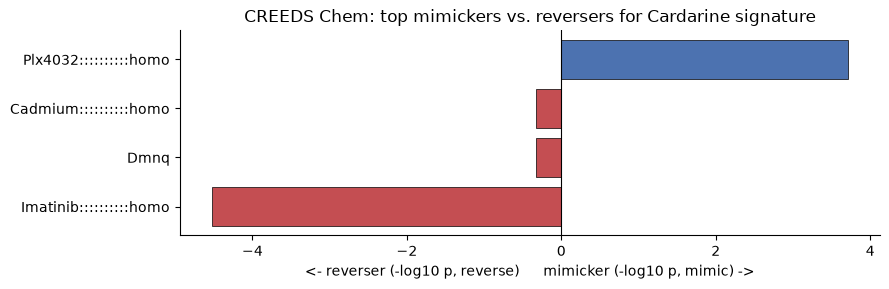

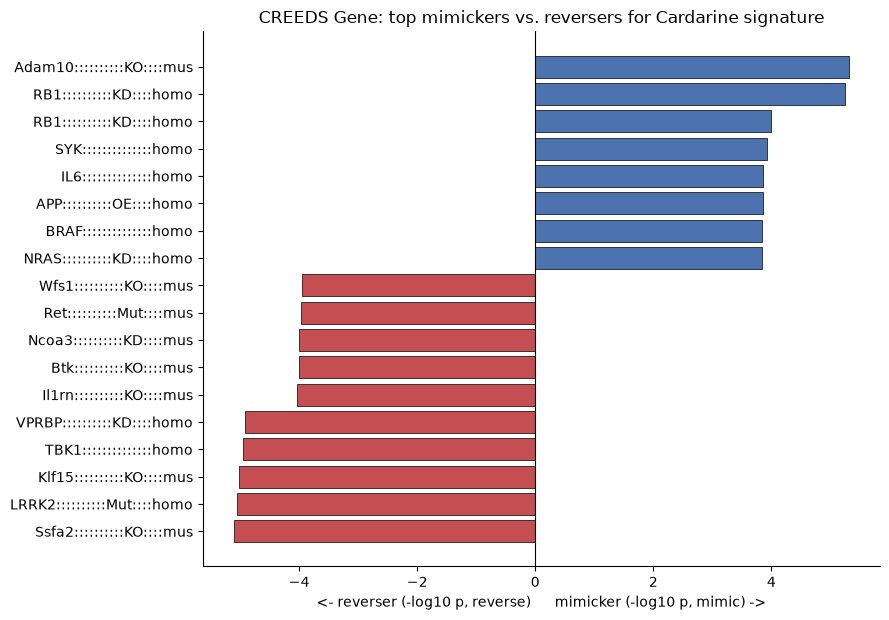

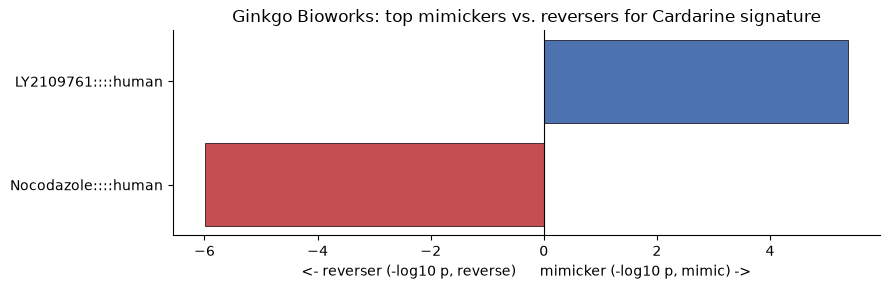

/var/folders/wx/60dd_d991tvbb_jrht5ps69m0000gn/T/ipykernel_2911/1783160851.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


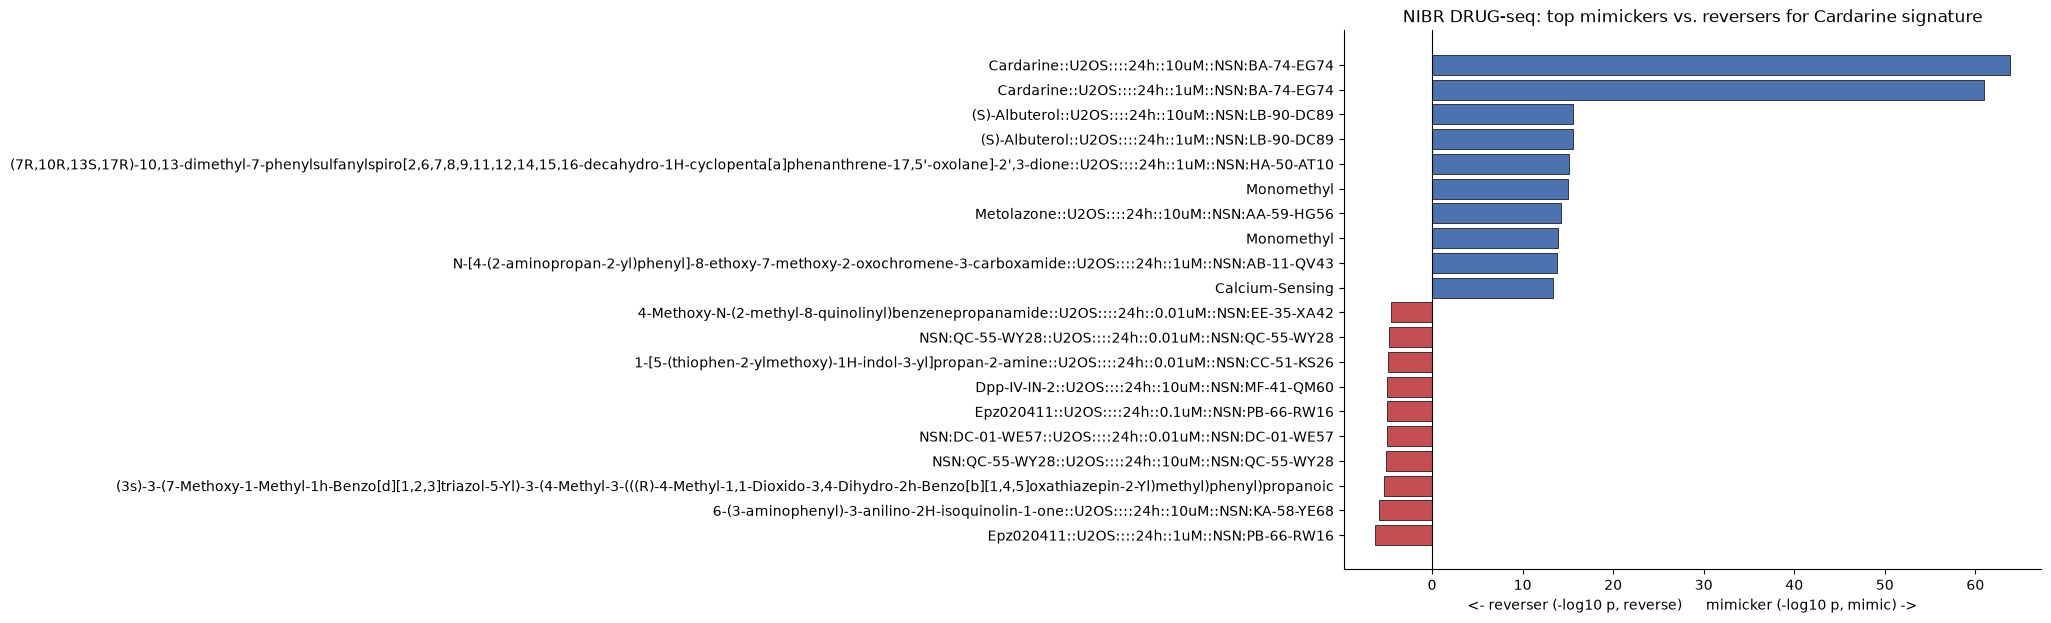

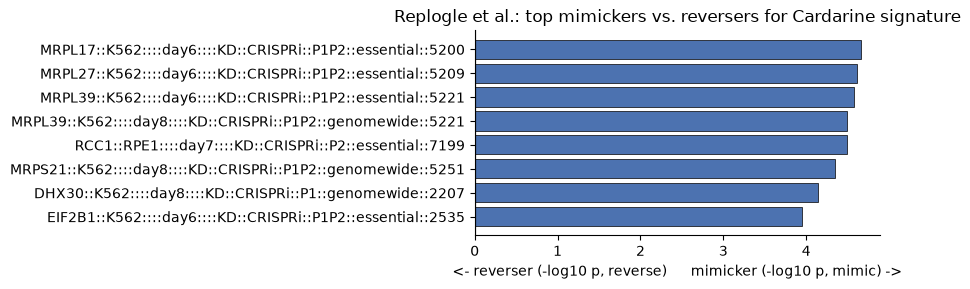

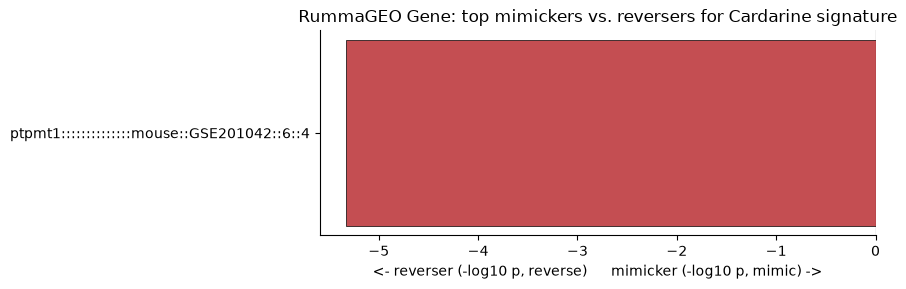

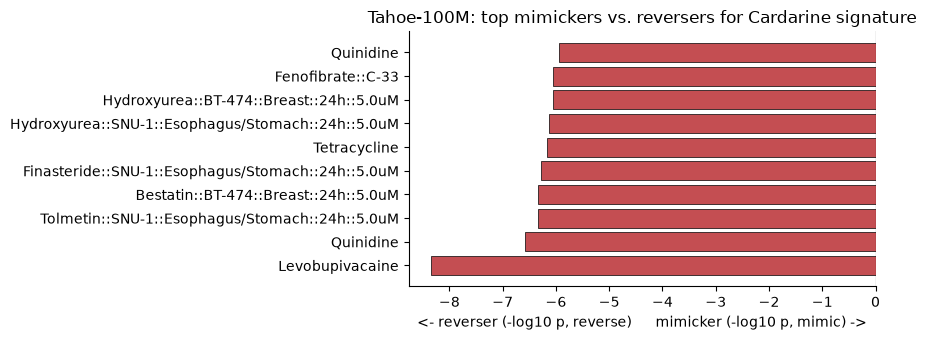

In [17]:
def make_perturbseqr_diverging_chart(library, df_mimic, df_reverse, top_n=10):
    """Diverging bar chart for one Perturb-Seqr library: top reversers (red, negative,
    extending left) vs. top mimickers (blue, positive, extending right)."""
    mim = df_mimic[df_mimic["library"] == library].sort_values("pvalueMimic").head(top_n) if not df_mimic.empty else df_mimic
    rev = df_reverse[df_reverse["library"] == library].sort_values("pvalueReverse").head(top_n) if not df_reverse.empty else df_reverse

    if mim.empty and rev.empty:
        return False

    mim_scores = -np.log10(mim["pvalueMimic"].clip(lower=1e-300)) if not mim.empty else pd.Series(dtype=float)
    rev_scores = np.log10(rev["pvalueReverse"].clip(lower=1e-300)) if not rev.empty else pd.Series(dtype=float)  # already negative

    rev_order = rev_scores.sort_values(ascending=True).index if not rev.empty else []
    mim_order = mim_scores.sort_values(ascending=True).index if not mim.empty else []

    labels = [rev.loc[i, "term"] for i in rev_order] + [mim.loc[i, "term"] for i in mim_order]
    scores = [rev_scores.loc[i] for i in rev_order] + [mim_scores.loc[i] for i in mim_order]
    colors = ["#C44E52"] * len(rev_order) + ["#4C72B0"] * len(mim_order)

    fig_h = max(3, 0.35 * len(labels))
    plt.figure(figsize=(9, fig_h))
    ax = plt.gca()
    ax.barh(range(len(labels)), scores, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("<- reverser (-log10 p, reverse)      mimicker (-log10 p, mimic) ->")
    ax.set_title(f"{library}: top mimickers vs. reversers for {SEARCH_TERM} signature")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    plt.tight_layout()

    safe_name = library.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"perturbseqr_{safe_name}_mimic_vs_reverse_bar.png", bbox_inches="tight")
    plt.show()
    return True


libraries_with_hits = sorted(
    set(df_enrichment_mimic["library"].dropna().unique() if not df_enrichment_mimic.empty else [])
    | set(df_enrichment_reverse["library"].dropna().unique() if not df_enrichment_reverse.empty else [])
)

if not libraries_with_hits:
    print("No per-library hits to chart.")
else:
    for library in libraries_with_hits:
        make_perturbseqr_diverging_chart(library, df_enrichment_mimic, df_enrichment_reverse, top_n=10)


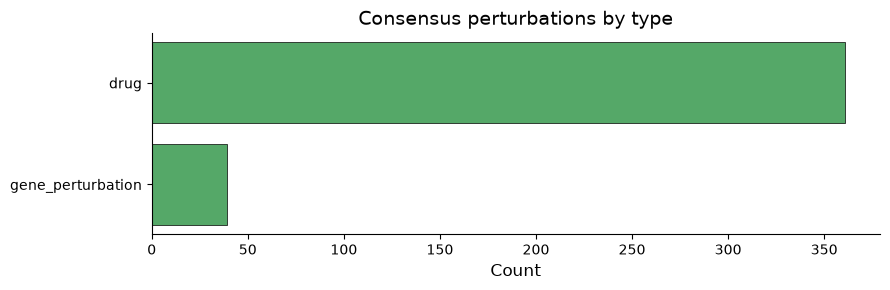

In [18]:
if not df_all_consensus.empty:
    type_counts = df_all_consensus["category"].value_counts()
    make_bar_chart(
        type_counts.index, type_counts.values,
        title="Consensus perturbations by type",
        xlabel="Count",
        colors="#55A868",
    )
    plt.savefig("perturbseqr_type_counts_bar.png", bbox_inches="tight")
    plt.show()
else:
    print("No consensus results to chart.")


In [19]:
# Optional: save everything to CSV for offline analysis
if not df_all_consensus.empty:
    df_hits.to_csv("cardarine_term_search_hits.csv", index=False)
    df_pairs.to_csv("cardarine_signature_pairs.csv", index=False)
    df_all_consensus.to_csv("cardarine_perturbseqr_consensus.csv", index=False)
    df_enrichment_mimic.to_csv("cardarine_perturbseqr_per_library_mimic.csv", index=False)
    df_enrichment_reverse.to_csv("cardarine_perturbseqr_per_library_reverse.csv", index=False)
    print("Saved: cardarine_term_search_hits.csv, cardarine_signature_pairs.csv, "
          "cardarine_perturbseqr_consensus.csv, cardarine_perturbseqr_per_library_mimic.csv, "
          "cardarine_perturbseqr_per_library_reverse.csv")


Saved: cardarine_term_search_hits.csv, cardarine_signature_pairs.csv, cardarine_perturbseqr_consensus.csv, cardarine_perturbseqr_per_library_mimic.csv, cardarine_perturbseqr_per_library_reverse.csv


In [21]:
import json

NIBR_LIBRARY_ID = "d47be9f1-8033-427b-8383-05a921748af6"

resp = requests.post(PERTURBSEQR_URL, json={
    "query": """
    query($libraryId: UUID!) {
      geneSets(condition: {libraryId: $libraryId}, first: 20) {
        nodes { term nGeneIds }
        totalCount
      }
    }
    """,
    "variables": {"libraryId": NIBR_LIBRARY_ID}
}, timeout=120)
res = resp.json()
print(json.dumps(res, indent=2)[:2500])

{
  "data": {
    "geneSets": {
      "nodes": [
        {
          "term": "NSN:WD-08-QT63::U2OS::::24h::0.01uM::NSN:WD-08-QT63 up",
          "nGeneIds": 5
        },
        {
          "term": "Nalmefene::U2OS::::24h::10uM::NSN:NC-52-HX69 up",
          "nGeneIds": 8
        },
        {
          "term": "N-Acetylserotonin::U2OS::::24h::0.01uM::NSN:DE-42-QB97 up",
          "nGeneIds": 10
        },
        {
          "term": "4-Bromo-2,6-diisopropylphenol::U2OS::::24h::1uM::NSN:JC-64-QI43 up",
          "nGeneIds": 66
        },
        {
          "term": "4-[1-amino-2-[[1-(4-chlorophenyl)cyclopropanecarbonyl]amino]ethyl]-N-pyridin-4-ylbenzamide::U2OS::::24h::10uM::NSN:GF-46-FA29 up",
          "nGeneIds": 48
        },
        {
          "term": "NSN:FF-46-CU92::U2OS::::24h::10uM::NSN:FF-46-CU92 up",
          "nGeneIds": 45
        },
        {
          "term": "NSN:LC-78-EV09::U2OS::::24h::0.1uM::NSN:LC-78-EV09 down",
          "nGeneIds": 7
        },
        {
         

## Notes

- **`pvalueMimic` / `oddsRatioMimic`** describe how strongly a candidate
  perturbation's *own* signature overlaps in the *same* direction as the query
  (up<->up, down<->down) -- high mimicry. **`pvalueReverse` / `oddsRatioReverse`**
  describe overlap in the *opposite* direction (up<->down) -- candidates that
  counteract the drug's effect.
- **`consensus`** aggregates evidence for a perturbation across all matching
  gene sets/datasets, so it's more robust than any single dataset hit.
- `MAX_SIGNATURES` in Step 3 caps how many signature pairs get the full
  downstream query -- raise it to cover every pair found in Step 2.
- If you want to search a different compound, just change `SEARCH_TERM` in
  Step 1 -- the rest of the pipeline (including the charts) is generic.
- Each per-library diverging chart shows at most the top 10 mimickers and top
  10 reversers for that library (`top_n` in `make_perturbseqr_diverging_chart`)
  -- raise it if a library has more hits worth seeing.
- Charts are also saved as PNGs (`perturbseqr_<library>_mimic_vs_reverse_bar.png`,
  `perturbseqr_type_counts_bar.png`) in the Colab working directory.
- Perturb-Seqr site: https://perturbseqr.maayanlab.cloud
